In [ ]:
import pandas as pd

#the file path to the CSV file
csv_file_path = "deliveries_with_paths.csv"

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Filter the DataFrame to show only completed deliveries
completed_deliveries = df[df['status'] == 'COMPLETED']

# Display the filtered DataFrame
print(completed_deliveries)

In [36]:
#Model for real data  
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the data
df = pd.read_csv("deliveries_with_paths.csv")

# Convert datetime columns
df['delivery_finished'] = pd.to_datetime(df['delivery_finished'])
df['delivery_started'] = pd.to_datetime(df['delivery_started'])

# Feature engineering
df['hour'] = df['delivery_finished'].dt.hour
df['minute'] = df['delivery_finished'].dt.minute
df['day_of_week'] = df['delivery_finished'].dt.dayofweek

# Calculate target (total delivery time in seconds)
df['total_delivery_time'] = (df['delivery_finished'] - df['delivery_started']).dt.total_seconds()

# Drop unnecessary rows and columns
df = df[df['status'] == 'COMPLETED']  # Only completed deliveries
X = df[['hour', 'minute', 'day_of_week', 'path', 'number_of_obstacles']]
y = df['total_delivery_time']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ['hour', 'minute', 'day_of_week']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['path'])
])

# Model pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Hyperparameter tuning
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Evaluate the model
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Mean Absolute Error (seconds): {mae:.2f}")
print(f"Mean Squared Error (seconds): {mse:.2f}")
print(f"R-squared: {r2:.2f}")




Best Parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Mean Absolute Error (seconds): 3.96
Mean Squared Error (seconds): 18.79
R-squared: 0.63


In [19]:
#cross-validation 
from sklearn.model_selection import cross_val_score

# Example: Cross-validate using negative MAE (to maximize performance)
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_absolute_error')
print(f"Average MAE from Cross-Validation: {abs(cv_scores.mean()):.2f}")


Average MAE from Cross-Validation: 3.54


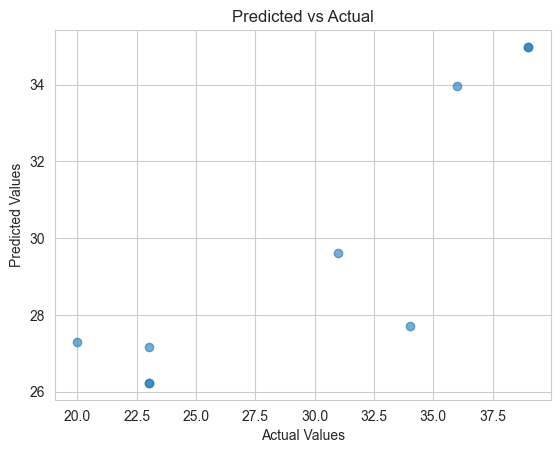

Test Data:
   hour  minute  day_of_week    path
0    10      15            0  Path 1
1    14      45            2  Path 2
2    18      30            4  Path 3
3    21       0            6  Path 1


In [21]:
import pandas as pd

# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Create a DataFrame with all combinations for each hour
hour_repeats = 3  # For 3 paths
minutes = list(range(26, 59))  # Minutes from 1 to 25
days_of_week = [4] * (hour_repeats * len(minutes))  # Same day for all entries
paths = ['Path 1', 'Path 2', 'Path 3'] * len(minutes)  # Cycle through paths

# Creating DataFrame
new_data = pd.DataFrame({
    'hour': [16, 17, 18] * len(minutes),
    'minute': minutes * hour_repeats,
    'day_of_week': days_of_week,
    'path': paths
})

# Predict using the best model
predicted_times = best_model.predict(new_data)
new_data['predicted_delivery_time'] = predicted_times

# Print the data
print(new_data)


    hour  minute  day_of_week    path  predicted_delivery_time
0     16      26            4  Path 1                35.224333
1     17      27            4  Path 2                30.098189
2     18      28            4  Path 3                25.908121
3     16      29            4  Path 1                35.224333
4     17      30            4  Path 2                29.303023
5     18      31            4  Path 3                25.382121
6     16      32            4  Path 1                35.393857
7     17      33            4  Path 2                29.166356
8     18      34            4  Path 3                25.037121
9     16      35            4  Path 1                35.220286
10    17      36            4  Path 2                29.178356
11    18      37            4  Path 3                24.277121
12    16      38            4  Path 1                35.330762
13    17      39            4  Path 2                29.439477
14    18      40            4  Path 3                24

In [35]:
# Corrected new_data with consistent column names
new_data = pd.DataFrame([
    {'hour': 16, 'minute': 59, 'day_of_week': 4, 'path': 'Path 1'},  # Use the same path names as training
    {'hour': 17, 'minute': 59, 'day_of_week': 4, 'path': 'Path 2'},
    {'hour': 18, 'minute': 59, 'day_of_week': 4, 'path': 'Path 3'}
])

# Ensure the new data is preprocessed by the pipeline
new_predictions = best_model.predict(new_data)

# Display predictions
for i, row in new_data.iterrows():
    print(
        f"Test Case {i+1}: Hour = {row['hour']}, Minute = {row['minute']}, "
        f"Day of Week = {row['day_of_week']}, Path = {row['path']}\n"
        f"Predicted Delivery Time = {new_predictions[i]:.2f} seconds\n"
    )


Test Case 1: Hour = 16, Minute = 59, Day of Week = 4, Path = Path 1
Predicted Delivery Time = 34.29 seconds

Test Case 2: Hour = 17, Minute = 59, Day of Week = 4, Path = Path 2
Predicted Delivery Time = 30.29 seconds

Test Case 3: Hour = 18, Minute = 59, Day of Week = 4, Path = Path 3
Predicted Delivery Time = 25.87 seconds

